# 06 - Extended Requirements: Noisy Expert + Observation Normalisation (E1, E2)

**Group members:** Marco De Palma, Em Echeverria, Leah Sarouphin, Juan Jose Rincon Briceño, Matteo Mainetti

The two bonus ablations, both on the from-scratch BC student and on both environments. These are heavy multi-seed sweeps (5 seeds each), so the figures are precomputed by `noise_sweep.py` (E1) and `norm_ablation.py` (E2); runtimes are in the README. All seeds are set.

In [1]:
import sys, os, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from src import seeding, config
seeding.set_seed(0)            # numpy + torch + python random
DEVICE = config.device()
OUT, MODELS, DATA = ROOT/'outputs', ROOT/'models', ROOT/'data'/'demonstrations'
def show(name):
    p = OUT/name
    display(Image(str(p))) if p.exists() else print('precomputed figure not found:', name,
        '- run the corresponding script (see README)')
def results(name):
    p = OUT/name
    return json.load(open(p)) if p.exists() else {}
print('setup ok | seeds set | device', DEVICE)

setup ok | seeds set | device mps


## E1 - Noisy expert: how robustly does BC learn from corrupted actions?

Zero-mean Gaussian noise of increasing std is added to the recorded expert actions (on the `[-1, 1]` torque scale, then clipped), the BC student is retrained across 5 seeds per level, and its deployed return is measured. The collapse point is the first std at which the student drops below half the expert's return.

Walker2d: collapse (below 50% of expert) at sigma >= 0.05
Ant: collapse (below 50% of expert) at sigma >= None


,env,sigma,ret,std,pct
0,Walker2d,0.00,4215,1203,70%
1,Walker2d,0.05,2754,663,46%
2,Walker2d,0.10,1884,213,31%
3,Walker2d,0.20,1300,103,22%
4,Walker2d,0.40,769,112,13%
5,Walker2d,0.80,282,27,5%
6,Ant,0.00,5897,160,95%
7,Ant,0.05,6253,225,101%
8,Ant,0.10,6151,275,100%
9,Ant,0.20,6317,200,102%


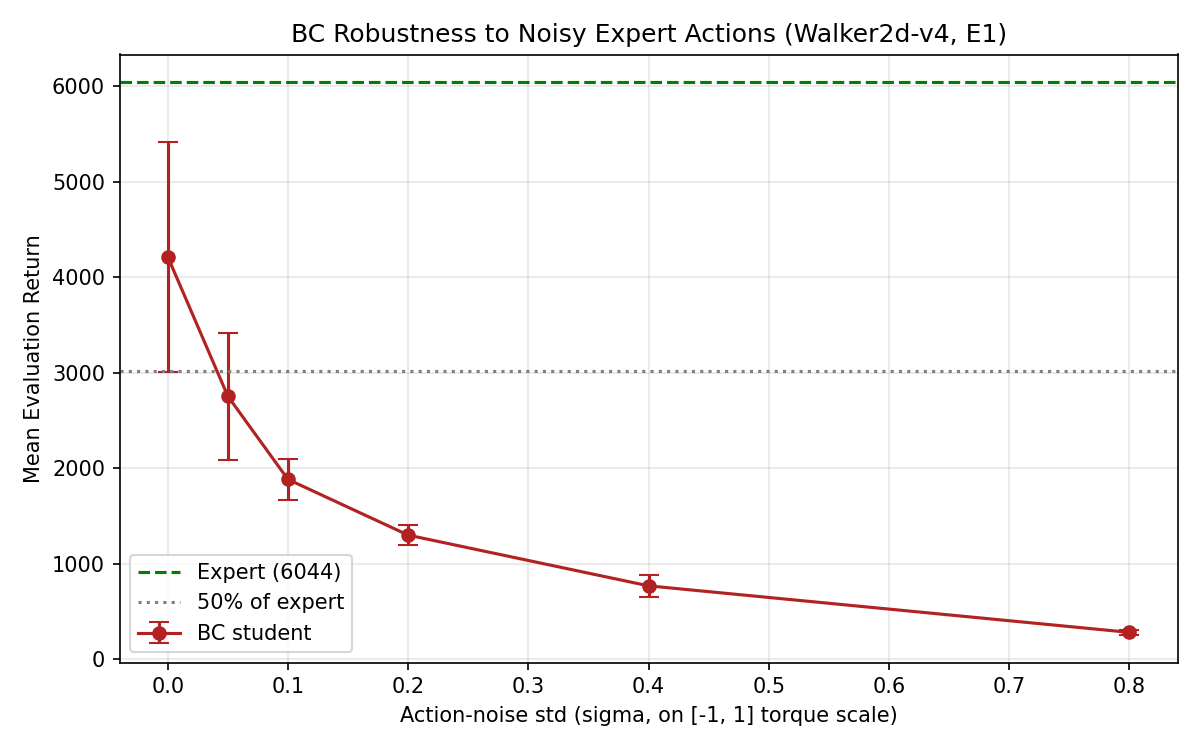

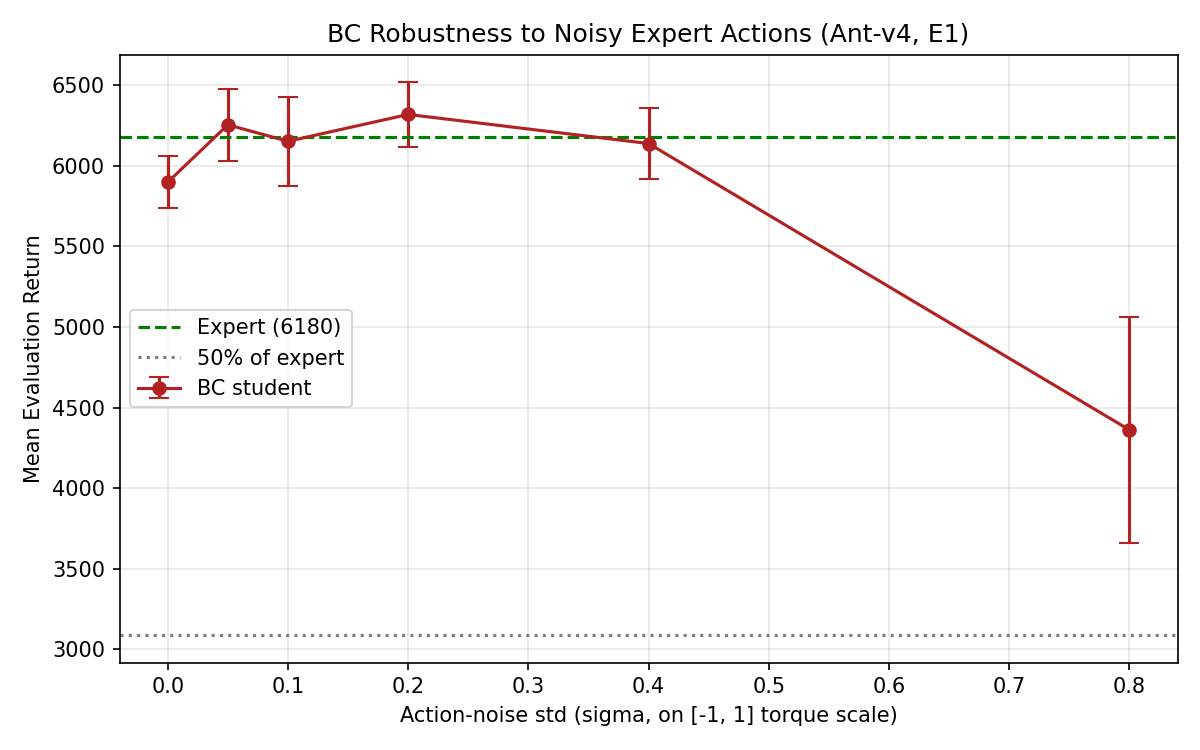

In [2]:
rows=[]
for k,label in {'Walker2d-v4':'Walker2d','Ant-v4':'Ant'}.items():
    r = results(f'bc_noise_sweep_{k}.json')
    if not r: continue
    em=r['expert_mean']; sig=r['sigmas']
    collapse=next((s for s in sig if r['noise'][str(s)]['mean']<0.5*em), None)
    for s in sig:
        n=r['noise'][str(s)]
        rows.append(dict(env=label, sigma=s, ret=round(n['mean']),
            std=round(n['std']), pct=f"{100*n['mean']/em:.0f}%"))
    print(f'{label}: collapse (below 50% of expert) at sigma >= {collapse}')
display(pd.DataFrame(rows))
show('bc_noise_sweep_Walker2d-v4.png'); show('bc_noise_sweep_Ant-v4.png')

## E2 - Observation normalisation: convergence speed and final return

The same BC student is trained with vs without standardising observations to zero mean / unit variance (using the demonstration set's own statistics, reused at evaluation), everything else held fixed. The left panel of each figure shows validation-MSE convergence; the right panel the final deployed return (5 seeds).

,env,expert,normalised,norm_ep,raw,raw_ep
0,Walker2d,6044,4654,150,1163,150
1,Ant,6180,5679,150,5946,150


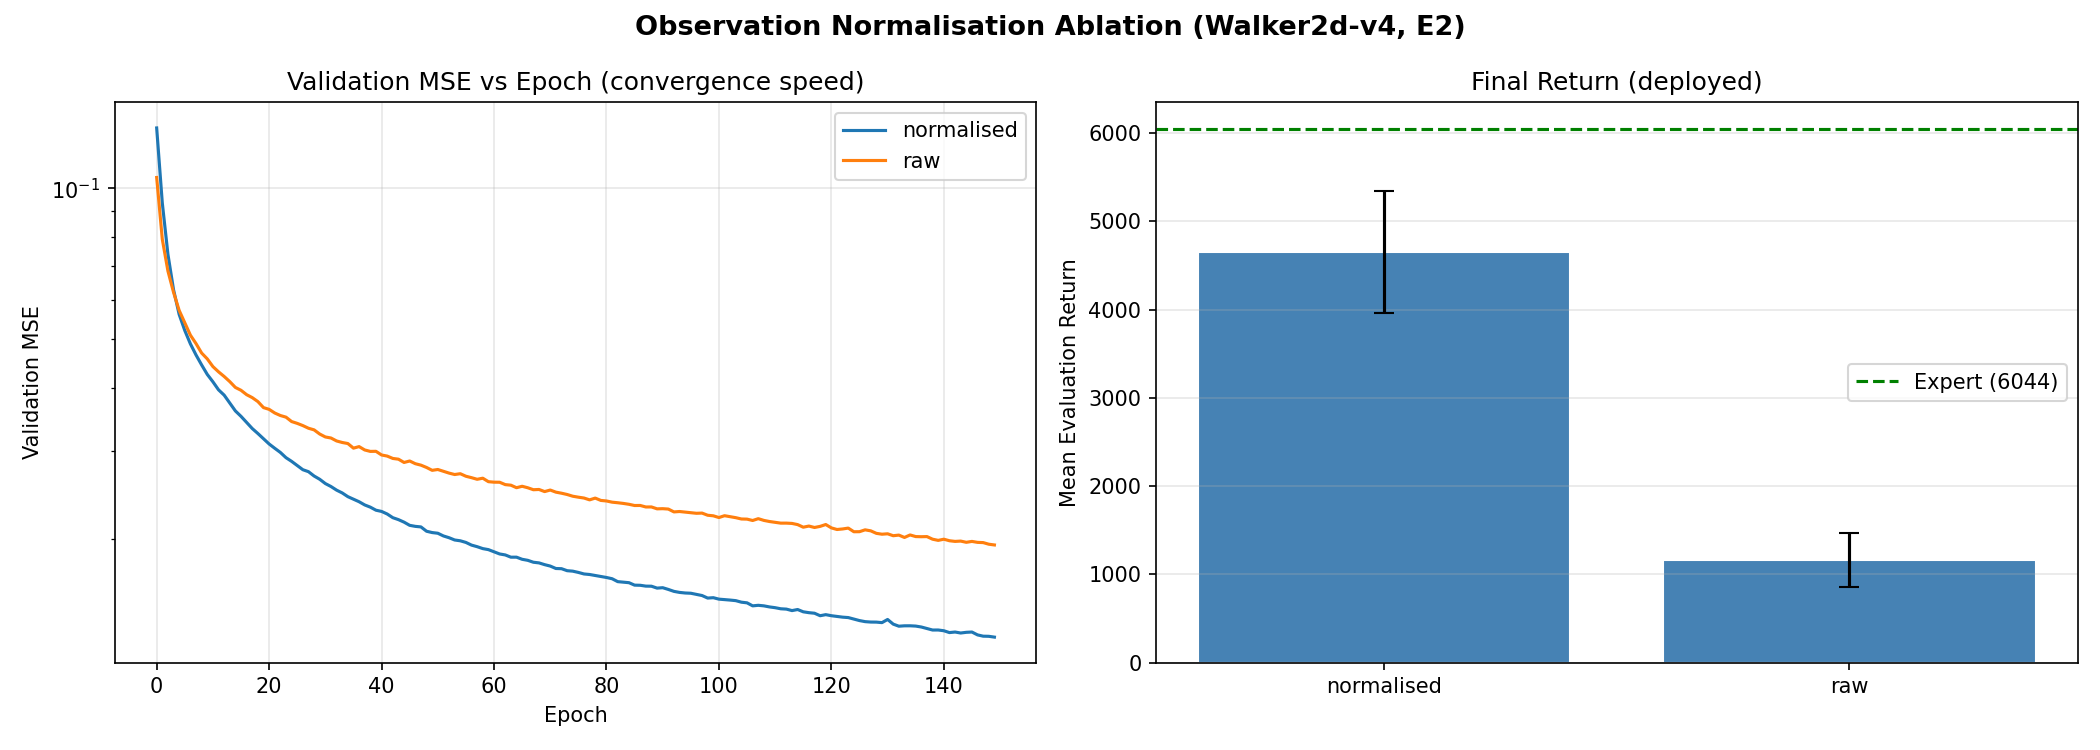

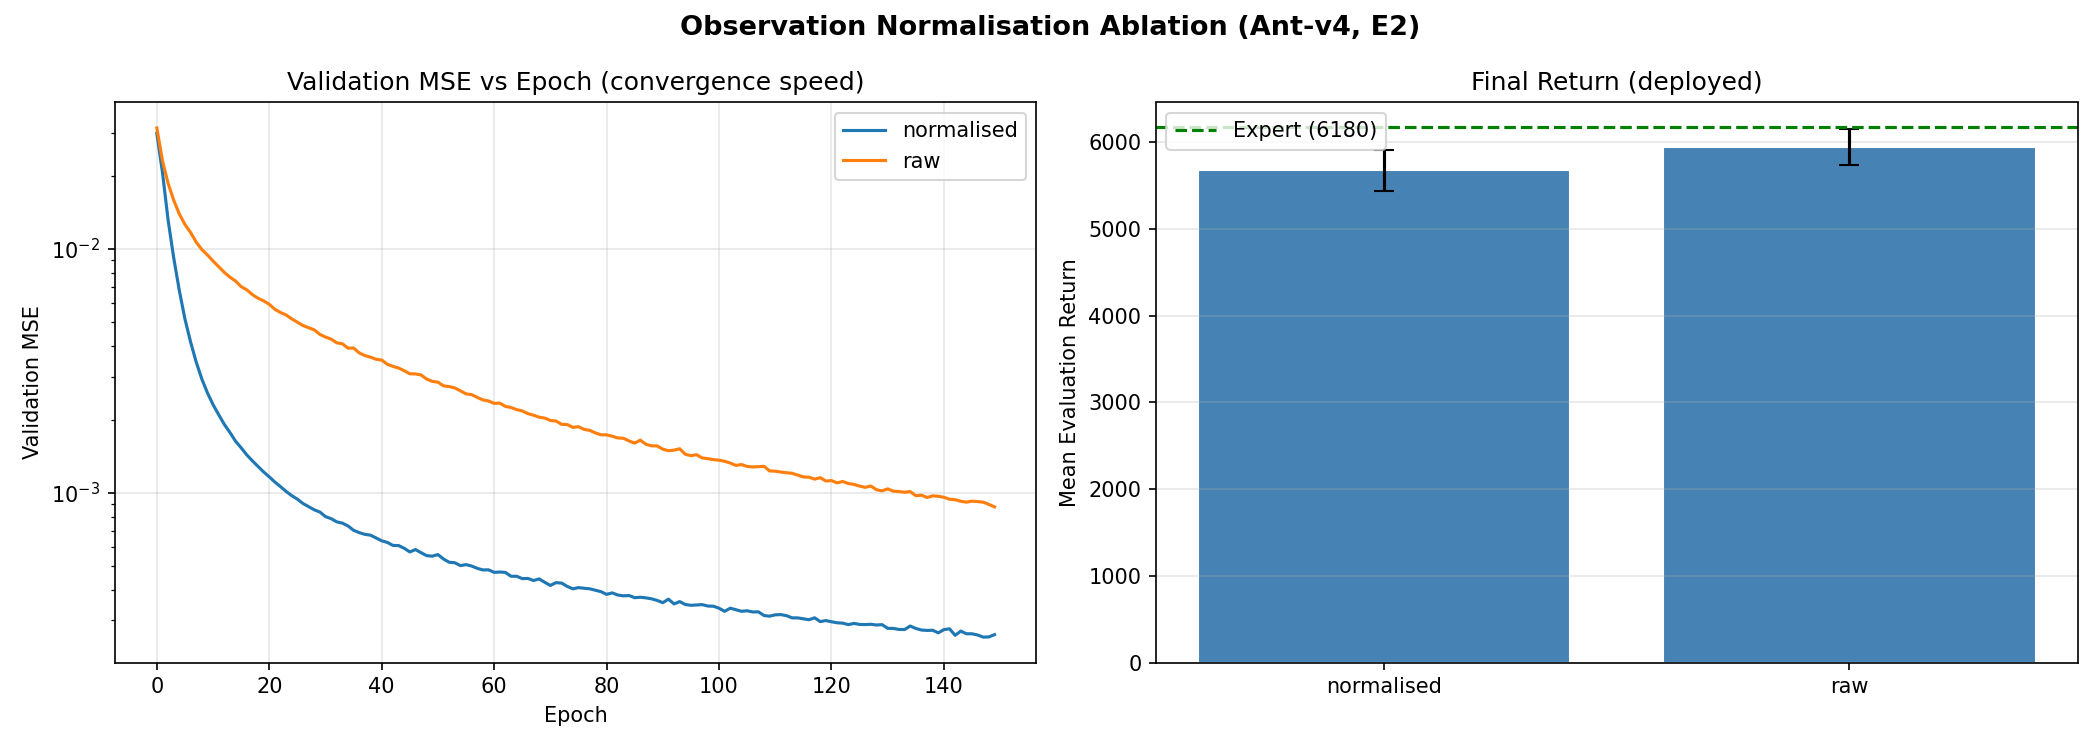

In [3]:
rows=[]
for k,label in {'Walker2d-v4':'Walker2d','Ant-v4':'Ant'}.items():
    r = results(f'bc_norm_ablation_{k}.json')
    if not r: continue
    em=r['expert_mean']; c=r['condition']
    rows.append(dict(env=label, expert=round(em),
        normalised=round(c['normalised']['mean']), norm_ep=c['normalised']['epochs_to_converge'],
        raw=round(c['raw']['mean']), raw_ep=c['raw']['epochs_to_converge']))
display(pd.DataFrame(rows))
show('bc_norm_ablation_Walker2d-v4.png'); show('bc_norm_ablation_Ant-v4.png')

## Findings

**E1 (noisy expert).** The two environments behave oppositely. On Walker2d the student is highly sensitive to action-label noise: even sigma=0.05 already drops it below half the expert return (46%), and performance decays monotonically to 5% at sigma=0.8, so the collapse point is essentially sigma ~ 0.05. On Ant the student is robust: it holds at 95-102% of the expert all the way through sigma=0.4 and only bends to 71% at sigma=0.8, never collapsing in the tested range. Noise also tightens Walker2d's seed variance as the policy uniformly degrades, while Ant's stays high until the largest noise. This mirrors RQ6: Ant's action mapping is easy to fit and tolerant of corrupted labels, whereas Walker2d's near-saturated control compounds even small label errors.

**E2 (observation normalisation).** Again environment-dependent. On Walker2d normalisation is decisive: standardising observations to zero mean / unit variance gives 4654 (77% of expert) versus 1163 (19%) on raw observations, a 4.0x gap, raw-observation BC effectively fails. On Ant it makes no difference: normalised 5679 (92%) versus raw 5946 (96%), within seed noise. Walker2d's observations contain large-magnitude velocity components that wreck Adam's conditioning without scaling, whereas Ant's better-conditioned observations are learnable raw. The convergence panels show the same pattern: on Walker2d the raw-obs validation loss sits far above the normalised curve throughout, on Ant the two overlap.

**Takeaway.** Both bonus studies reinforce the central cross-environment finding: Walker2d is fragile to imperfect imitation conditions (it needs clean labels and normalised inputs), while Ant is robust to both. Imitation difficulty, not state dimensionality, governs sensitivity.